In [1]:
import slangpy as spy
from pyglm import glm
import matplotlib.pyplot as plt
import numpy as np
import quaternion
from PIL import Image
import pathlib
import jax
import jax.numpy as jnp


from bvhgs import device
from bvhgs.camera import Camera
from bvhgs.gaussian import GaussianCloud
from bvhgs.renderer import Renderer
from bvhgs.prefix_sum import prefix_sum
from bvhgs.radix_sort import radix_sort, numpy_sort
from bvhgs.data import SFMDataset

In [2]:
np.random.seed(0)

# Load Gaussian Buffer

In [3]:
gaussians = GaussianCloud()
gaussians.load_from_colmap(pathlib.Path("../resources/dataset/tandt_db/tandt/truck/sparse/0/"), scale_factor=-3, opacity_factor=0)
len(gaussians)

104692

# Load Module and Shader

In [4]:
module = device.load_module("renderer.slang")
module

SlangModule(
  name = renderer.slang,
  path = D:\Projects\bvhgs\src\bvhgs\slang\renderer.slang,
  entry_points = [
    SlangEntryPoint(name="project", stage=compute),
    SlangEntryPoint(name="cull", stage=compute),
    SlangEntryPoint(name="bwdCullProjection", stage=compute),
    SlangEntryPoint(name="computeTile", stage=compute),
    SlangEntryPoint(name="buildGaussianTable", stage=compute),
    SlangEntryPoint(name="tileHistogram", stage=compute),
    SlangEntryPoint(name="duplicateGaussian", stage=compute),
    SlangEntryPoint(name="rasterize", stage=compute),
    SlangEntryPoint(name="bwdRasterize", stage=compute),
    SlangEntryPoint(name="bwdDuplicateGaussian", stage=compute),
    SlangEntryPoint(name="extractCulledGaussianGrad", stage=compute),
    SlangEntryPoint(name="gradDescentGaussian3D", stage=compute),
  ]
)

In [5]:
program = device.link_program([module], [])
program

ShaderProgram(
  modules = [
    SlangModule(
      name = renderer.slang,
      path = D:\Projects\bvhgs\src\bvhgs\slang\renderer.slang,
      entry_points = [
        SlangEntryPoint(name="project", stage=compute),
        SlangEntryPoint(name="cull", stage=compute),
        SlangEntryPoint(name="bwdCullProjection", stage=compute),
        SlangEntryPoint(name="computeTile", stage=compute),
        SlangEntryPoint(name="buildGaussianTable", stage=compute),
        SlangEntryPoint(name="tileHistogram", stage=compute),
        SlangEntryPoint(name="duplicateGaussian", stage=compute),
        SlangEntryPoint(name="rasterize", stage=compute),
        SlangEntryPoint(name="bwdRasterize", stage=compute),
        SlangEntryPoint(name="bwdDuplicateGaussian", stage=compute),
        SlangEntryPoint(name="extractCulledGaussianGrad", stage=compute),
        SlangEntryPoint(name="gradDescentGaussian3D", stage=compute),
      ]
    ),
  ],
  entry_points = []
)

# Build Slang Buffer and Camera Parameter

In [6]:
# Create a buffer for the Gaussian points.
gaussian_3d_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_gaussian_3d,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
# Store all the gaussian points in the buffer.
gaussian_cursor = spy.BufferCursor(
    program.reflection.g_gaussian_3d.type_layout.element_type_layout,
    gaussian_3d_buf,
)

for i in range(len(gaussians)):
    gaussian_cursor[i].write(gaussians[i])
gaussian_cursor.apply()

In [7]:
sfm_dataset = SFMDataset()
sfm_dataset.load_from_colmap(
    colmap_path=pathlib.Path("../resources/dataset/tandt_db/tandt/truck/sparse/0/"),
    image_dir=pathlib.Path("../resources/dataset/tandt_db/tandt/truck/images/")
)

{'_rotation': [-0.03458227962255478, 0.32694852352142334, 0.0032672483939677477, 0.9444036483764648], '_translation': vec3( -1.23324, -0.470908, 3.94508 ), '_sensorSize': uvec2( 979, 546 ), '_focalLength': 581.9245354745742, '_nearPlane': 0.1, '_farPlane': 1000.0}


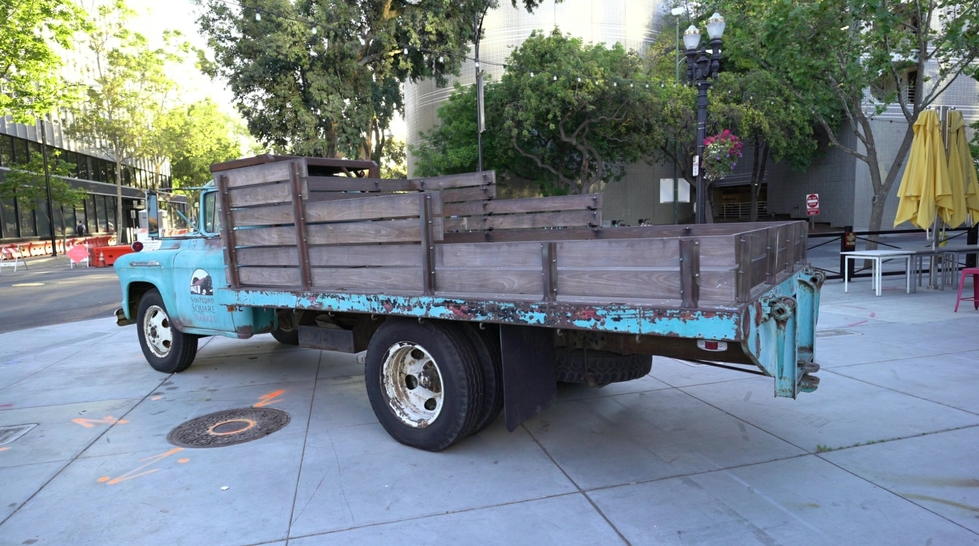

In [8]:
camera, image_path = sfm_dataset[0]
print(camera.to_slang())
image = Image.open(image_path)
image

# Projection

## Dispatch Projection Kernel

In [9]:
# Create a buffer for the Gaussian2D points.
gaussian2d_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_gaussian_2d,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian2d_buf

Buffer(
  device = 0x21dc140cfc8,
  size = 4606448,
  struct_size = 44,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 4.39 MB,
  label = 
)

In [10]:
# Create flag buffer for culling.
inside_flag_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_inside_flag,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
inside_flag_buf

Buffer(
  device = 0x21dc140cfc8,
  size = 418768,
  struct_size = 4,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 408.95 kB,
  label = 
)

In [11]:
ker_proj = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("project")])
)
ker_proj

ComputeKernel(0x21dd03a7c40)

In [12]:
ker_proj.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_gaussian_3d": gaussian_3d_buf,
        "g_gaussian_2d": gaussian2d_buf,
        "g_inside_flag": inside_flag_buf
    }
)

In [13]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_2d.type_layout.element_type_layout,
    gaussian2d_buf,
)
cursor.element_count
cursor[0]

{'position': {0.237611, 0.5327741, 0.0039648735}, 'covariance': {{5.3014162e-05, -2.9855786e-13}, {-1.1993678e-14, 0.00017044017}}, 'color': {0.488279, 0.5273407, 0.60937047}, 'opacity': 0.5} [Gaussian2D]

## Cull Gaussians

In [14]:
ker_cull = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("cull")])
)

In [15]:
# Cull the Gaussian points.
inside_offset_buf = prefix_sum(inside_flag_buf)
inside_offset_cursor = spy.BufferCursor(
    program.reflection.g_inside_offset.type_layout.element_type_layout,
    inside_offset_buf,
)
# Read the last element of the cull prefix buffer to get the number of culled points.
num_viewing = int(inside_offset_cursor[len(inside_offset_cursor) - 1].read())  # type: ignore
num_viewing

94589

In [16]:
# Culled gaussians
culled_gaussian_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.g_gaussian_2d_culled,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
culled_gaussian_buf

Buffer(
  device = 0x21dc140cfc8,
  size = 4161916,
  struct_size = 44,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 3.97 MB,
  label = 
)

In [17]:
ker_cull.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_gaussian_2d": gaussian2d_buf,
        "g_inside_flag": inside_flag_buf,
        "g_inside_offset": inside_offset_buf,
        "g_gaussian_2d_culled": culled_gaussian_buf
    }
)

In [18]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_2d_culled.type_layout.element_type_layout,
    culled_gaussian_buf,
)
cursor[0]

{'position': {0.237611, 0.5327741, 0.0039648735}, 'covariance': {{5.3014162e-05, -2.9855786e-13}, {-1.1993678e-14, 0.00017044017}}, 'color': {0.488279, 0.5273407, 0.60937047}, 'opacity': 0.5} [Gaussian2D]

# Tiling

In [19]:
ker_tile = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("computeTile")])
)
ker_build_gs = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("buildGaussianTable")])
)

In [20]:
num_tile_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.g_num_tiles,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
num_tile_buf

Buffer(
  device = 0x21dc140cfc8,
  size = 378356,
  struct_size = 4,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 369.49 kB,
  label = 
)

In [21]:
ker_tile.dispatch(
    thread_count=[num_viewing, 1, 1],
    numViewing=num_viewing,
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_num_tiles": num_tile_buf
    }
)

In [22]:
num_tile_arr = num_tile_buf.to_numpy().view(np.uint32)
num_table_entries = np.sum(num_tile_arr).item()
num_table_entries

495160

In [23]:
gaussian_table_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.g_gaussian_table,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian_table_buf

Buffer(
  device = 0x21dc140cfc8,
  size = 7922560,
  struct_size = 16,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 7.56 MB,
  label = 
)

In [24]:
num_tile_prefix_buf = prefix_sum(num_tile_buf)

In [25]:
ker_build_gs.dispatch(
    thread_count=[num_viewing, 1, 1],
    numViewing=num_viewing,
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_num_tiles_prefix": num_tile_prefix_buf,
        "g_gaussian_table": gaussian_table_buf,
    }
)

# Sort Tile

In [26]:
numpy_sort(gaussian_table_buf)

In [27]:
ker_tile_hist = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("tileHistogram")])
)

In [28]:
hist_buf = device.create_buffer(
    element_count=2**8,
    struct_type=program.reflection.g_tile_hist_atomic,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)
# Compute the histogram of the Gaussian table.
ker_tile_hist.dispatch(
    thread_count=[num_table_entries, 1, 1],
    numEntries=num_table_entries,
    vars={
        "g_gaussian_table": gaussian_table_buf,
        "g_tile_hist_atomic": hist_buf,
    },
)

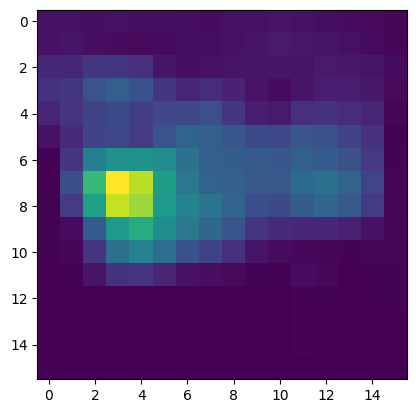

In [29]:
plt.imshow(hist_buf.to_numpy().view(np.uint32).reshape(16, 16))

# Rasterize

In [30]:
ker_duplicate = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("duplicateGaussian")])
)
ker_rasterize = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("rasterize")])
)

In [31]:
gaussian_2d_sorted_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.g_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian_2d_sorted_buf

Buffer(
  device = 0x21dc140cfc8,
  size = 21787040,
  struct_size = 44,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 20.78 MB,
  label = 
)

In [32]:
ker_duplicate.dispatch(
    thread_count=[num_table_entries, 1, 1],
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_gaussian_table": gaussian_table_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf
    }
)

In [33]:
render_target = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

depth_target = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

num_depth_buf = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.r32_uint,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

In [34]:
hist_arr = hist_buf.to_numpy().view(np.uint32)
hist_offs = np.zeros_like(hist_arr)
hist_offs[1:] = np.cumsum(hist_arr)[:-1]

In [35]:
tile_offst_buf = device.create_buffer(
    element_count=len(hist_offs),
    struct_type=program.reflection.g_tile_offs,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
tile_offst_buf.copy_from_numpy(hist_offs)

In [36]:
ker_rasterize.dispatch(
    thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_tile_hist": hist_buf,
        "g_tile_offs": tile_offst_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
        "g_render_target": render_target,
        "g_depth_target": depth_target,
        "g_num_rendered_gaussians": num_depth_buf,
    }
)

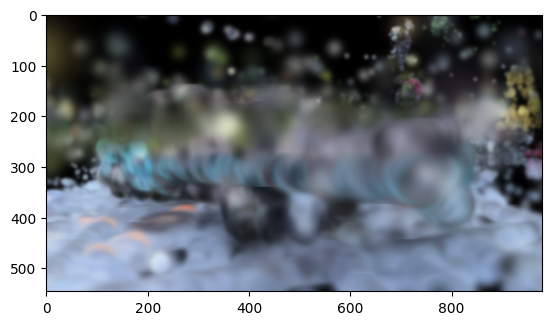

In [37]:
unoptimized_raw_image = jnp.array(render_target.to_numpy()[:, :, :3])
plt.imshow(unoptimized_raw_image)

# Image Loss

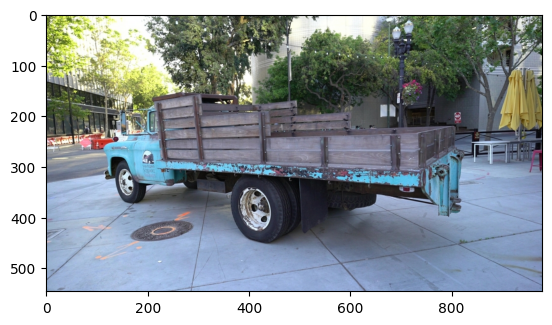

In [38]:
image_arr = jnp.array(image).astype(jnp.float32) / 255.0
plt.imshow(image_arr)

In [39]:
def image_loss(src: jnp.ndarray, dst: jnp.ndarray):
    return jnp.mean((dst - src)**2)

In [40]:
image_loss(unoptimized_raw_image, image_arr)

Array(0.09586918, dtype=float32)

In [41]:
# Image grad.
loss_grad = jax.value_and_grad(image_loss)

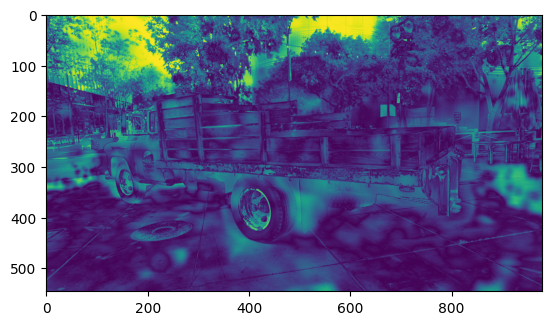

In [42]:
loss, render_target_grad = loss_grad(unoptimized_raw_image, image_arr)
plt.imshow(jnp.linalg.norm(render_target_grad, axis=-1))

In [43]:
render_target_grad.shape

(546, 979, 3)

In [44]:
rg_shape = render_target_grad.shape
render_target_grad = jnp.concatenate((render_target_grad, jnp.zeros((rg_shape[0], rg_shape[1], 1))), axis=-1)
render_target_grad.shape

(546, 979, 4)

# Backward Gradient into Slang

In [45]:
ker_bwd_rasterize = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("bwdRasterize")])
)
ker_bwd_duplicate = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("bwdDuplicateGaussian")])
)
ker_bwd_cull_proj = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("bwdCullProjection")])
)
ker_grad_descent = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("gradDescentGaussian3D")])
)

ker_extract_culled_gaussian = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("extractCulledGaussianGrad")])
)

In [46]:
grad_texture = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

In [47]:
grad_texture.copy_from_numpy(render_target_grad)

In [48]:
a_gaussian_2d_sorted_grad_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.d_a_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)

a_gaussian_2d_culled_grad_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.d_a_gaussian_2d_culled,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)

gaussian_2d_culled_grad_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.d_gaussian_2d_culled,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)

gaussian_3d_grad_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.d_gaussian_3d,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)

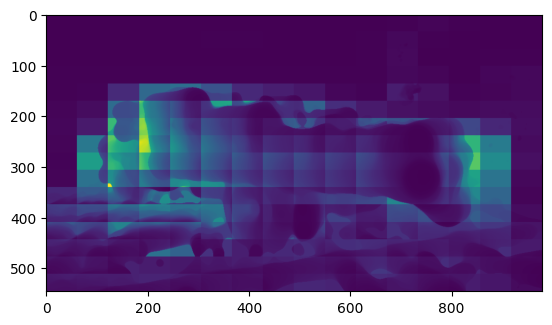

In [49]:
num_depth_buf.to_numpy().view(np.uint32)
plt.imshow(num_depth_buf.to_numpy().view(np.uint32))

In [50]:
ker_bwd_rasterize.dispatch(
    thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_tile_hist": hist_buf,
        "g_tile_offs": tile_offst_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
        "g_render_target": render_target,
        "g_num_rendered_gaussians": num_depth_buf,
        "d_render_target": grad_texture,
        "d_a_gaussian_2d_sorted": a_gaussian_2d_sorted_grad_buf,
        
    }
)

#bwd duplicate
ker_bwd_duplicate.dispatch(
    thread_count=[num_table_entries, 1, 1],
    vars={
        "g_gaussian_table": gaussian_table_buf,
        "d_a_gaussian_2d_sorted": a_gaussian_2d_sorted_grad_buf,
        "d_a_gaussian_2d_culled": a_gaussian_2d_culled_grad_buf,
    }
)

# Extract the gradients for the culled Gaussian 2D points.
ker_extract_culled_gaussian.dispatch(
    thread_count=[num_viewing, 1, 1],
    vars={
        "d_gaussian_2d_culled": gaussian_2d_culled_grad_buf,
        "d_a_gaussian_2d_culled": a_gaussian_2d_culled_grad_buf,
    }
)


# bwd cull and projection
ker_bwd_cull_proj.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_gaussian_3d": gaussian_3d_buf,
        "g_inside_flag": inside_flag_buf,
        "g_inside_offset": inside_offset_buf,
        "d_gaussian_2d_culled": gaussian_2d_culled_grad_buf,
        "d_gaussian_3d": gaussian_3d_grad_buf,
    }
)

In [51]:
arr = a_gaussian_2d_sorted_grad_buf.to_numpy().view(np.float32).reshape(num_table_entries, -1)
np.max(arr, axis=0), np.min(arr, axis=0)

(array([1.2064243e-02, 1.2559822e-02, 0.0000000e+00, 1.0427312e+00,
        2.4111065e-01, 2.4111068e-01, 3.0863065e-01, 5.1299761e-05,
        5.3190583e-05, 5.9346934e-05, 2.1535232e-04], dtype=float32),
 array([-1.9030275e-02, -1.3840382e-02,  0.0000000e+00, -2.8163552e+00,
        -2.7557880e-01, -2.7557895e-01, -5.9623003e-01, -3.9291859e-04,
        -3.9432442e-04, -3.7877899e-04, -9.1429130e-04], dtype=float32))

In [52]:
arr = a_gaussian_2d_culled_grad_buf.to_numpy().view(np.float32).reshape(num_viewing, -1)
np.max(arr, axis=0), np.min(arr, axis=0)

(array([1.0006401e-02, 6.5480922e-03, 0.0000000e+00, 1.6009389e+00,
        1.8056139e-01, 1.8056141e-01, 4.8731810e-01, 6.5866610e-05,
        7.6837263e-05, 8.6941967e-05, 6.6447817e-04], dtype=float32),
 array([-4.1398734e-02, -7.9000583e-03,  0.0000000e+00, -3.4271598e+00,
        -1.4448079e-01, -1.4448081e-01, -1.0509052e+00, -1.6034477e-03,
        -1.6527759e-03, -1.1868239e-03, -3.2024537e-03], dtype=float32))

In [53]:
arr = gaussian_3d_grad_buf.to_numpy().view(np.float32).reshape(len(gaussians), -1, 4)[:, :5, :]
np.max(arr, axis=0), np.min(arr, axis=0)

ValueError: cannot reshape array of size 6176828 into shape (104692,newaxis,4)

## A Very Simple Gradient Descent

In [54]:
import logging
logging.basicConfig(level=logging.WARN)

In [55]:
from bvhgs.renderer import Renderer
from tqdm.auto import tqdm

renderer = Renderer(gaussians, camera)

In [ ]:
arr = renderer.gaussian_3d_buf.to_numpy().view(np.float32).reshape(len(gaussians), -1, 4)[:, :5, :]
np.max(arr, axis=0), np.min(arr, axis=0)

ValueError: cannot reshape array of size 6176828 into shape (104692,newaxis,4)

In [ ]:
num_epoch = 3
lr = 0.005
optimizer_update_interval = 5
optimizer_step = 0

# randomize index order from 0 to len(sfm_dataset) - 1
indices = np.random.permutation(len(sfm_dataset))

for epoch in range(num_epoch):
    print(f"Epoch {epoch + 1}/{num_epoch}")

    running_loss = 0.0

    pbar = tqdm(range(len(sfm_dataset)))
    for i in pbar:
        
        renderer.zero_grad()
        camera, image_path = sfm_dataset[indices[i]]
        image = Image.open(image_path)

        renderer.camera = camera

        loss = renderer.render(gt_image=image)
        renderer.backward(lr=lr,
                          beta1=0.95,
                          beta2=0.999,
                          weight_decay=1e-4)
        pbar.set_description(f"Training loss: {loss:.6f}")

        running_loss += loss
        
        optimizer_step += 1
        if optimizer_step % optimizer_update_interval == 0:
            renderer.optimizer_step()
        
        
        

    running_loss /= len(sfm_dataset)
    print(f"Epoch {epoch + 1}/{num_epoch}, Loss: {running_loss:.6f}")

Epoch 1/3


  0%|          | 0/251 [00:00<?, ?it/s]

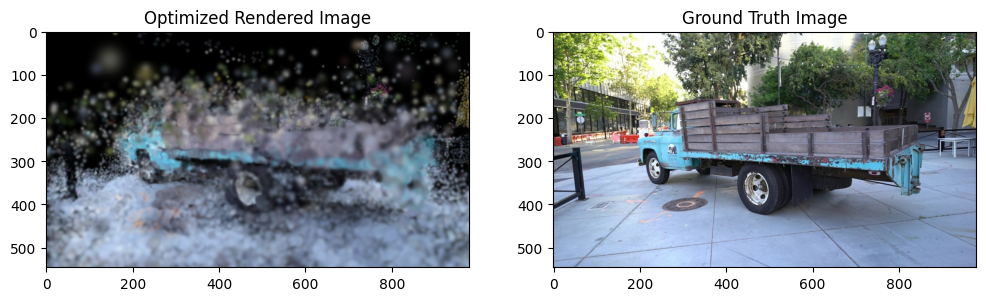

In [65]:
#render
camera, image_path = sfm_dataset[2]
image = Image.open(image_path)

renderer.camera = camera
renderer.render()

render_target = renderer.render_target
raw_image = jnp.array(render_target.to_numpy()[:, :, :3])

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(raw_image)
ax[0].set_title("Optimized Rendered Image")
ax[1].imshow(jnp.array(image).astype(jnp.float32) / 255.0)
ax[1].set_title("Ground Truth Image")
plt.show()

In [ ]:
arr = renderer.gaussian_3d_grad_buf.to_numpy().view(np.float32).reshape(len(gaussians), -1, 4)[:, :8, :]
np.max(arr, axis=0), np.min(arr, axis=0)

(array([[1.04338559e-03, 5.10624959e-04, 9.03606531e-04, 0.00000000e+00],
        [1.45605882e-04, 1.20794866e-03, 5.96766913e-05, 1.17720477e-03],
        [2.67817464e-04, 3.11149255e-04, 2.24450887e-05, 0.00000000e+00],
        [1.31117895e-05, 1.15191206e-05, 2.72549569e-05, 0.00000000e+00],
        [2.89919728e-04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [4.99153066e-05, 4.86866047e-05, 5.30401485e-05, 0.00000000e+00],
        [1.02802995e-03, 1.82149769e-03, 1.73348491e-03, 0.00000000e+00],
        [6.91995592e-05, 6.74961630e-05, 7.35316498e-05, 0.00000000e+00]],
       dtype=float32),
 array([[-3.70926806e-04, -3.14015942e-03, -5.23310679e-04,
          0.00000000e+00],
        [-4.97131748e-03, -1.23919046e-04, -1.35951908e-03,
         -1.19754085e-02],
        [-3.42464977e-04, -6.12817612e-03, -3.74717238e-05,
          0.00000000e+00],
        [-6.00781095e-05, -1.22850455e-04, -4.71371168e-04,
          0.00000000e+00],
        [-1.14318589e-02,  0.0000000

In [ ]:
arr = renderer.gaussian_3d_buf.to_numpy().view(np.float32).reshape(len(gaussians), -1, 4)[:, :5, :]
np.max(arr, axis=0), np.min(arr, axis=0)

(array([[ 9.976342  ,  7.334748  ,  9.915626  ,  0.        ],
        [ 0.03771002,  0.02395776,  0.03554363,  1.0000001 ],
        [ 4.3386703 ,  3.2884407 , -1.6222079 ,  0.        ],
        [ 5.540112  ,  5.5401773 ,  5.539414  ,  0.        ],
        [ 0.60811794,  0.        ,  0.        ,  0.        ]],
       dtype=float32),
 array([[-9.8033371e+00, -6.7354274e+00, -9.8346138e+00,  0.0000000e+00],
        [-1.5073090e-03, -9.5036499e-02, -9.7842736e-04,  9.9412405e-01],
        [-3.1206584e+00, -3.1345580e+00, -3.0829921e+00,  0.0000000e+00],
        [-1.1512925e+01, -1.1512925e+01, -1.1512925e+01,  0.0000000e+00],
        [-6.6659689e-02,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],
       dtype=float32))